# Giorno 1 — Fondamenti, Trapdoor, RSA e Giochi di Sicurezza

Esercitazione pomeridiana. Percorso:

1. **Merkle Puzzles**: un key exchange "onesto" ma inefficiente → perché serve una vera *trapdoor function*.
2. **Aritmetica modulare e gruppi ciclici**: la base matematica di RSA (esplorazione interattiva).
3. **RSA da zero**: keygen, cifratura, decifratura.
4. **RSA "textbook" è insicuro**: determinismo e malleabilità.
5. **Il gioco IND-CPA / IND-CCA**: dallo schema nudo a OAEP, passando per un padding oracle giocattolo.
6. **Quanto costa la crittografia asimmetrica?** Benchmark RSA vs AES.

> Ogni sezione segue lo stesso schema: primitiva nuda → attacco dal vivo → contromisura → takeaway.


In [1]:
import os, time, random, math
from Crypto.Cipher import AES, PKCS1_OAEP
from Crypto.PublicKey import RSA as RSA_lib
from Crypto.Util.Padding import pad, unpad
from Crypto.Util.number import getPrime, inverse, GCD
import matplotlib.pyplot as plt
import sympy

random.seed(42)
print("Ambiente pronto.")


Ambiente pronto.


## 1. Precondivisione delle chiavi

Il problema principale della crittografia asimmetrica e' che si presuppone delle chiavi pre-condivise tra ogni coppia di entita' che vogliono comunicare


## 1. Merkle Puzzles — key exchange senza trapdoor

**Idea**: Alice prepara $N$ "puzzle": ciascuno è una chiave di sessione cifrata con una chiave-puzzle
volutamente debole (pochi bit). Li manda tutti a Bob. Bob ne sceglie uno a caso e lo rompe per forza bruta
(costo $O(K)$, con $K$ = spazio delle chiavi-puzzle). Da quel momento Alice e Bob condividono la chiave di
sessione contenuta in quel puzzle.

**Il punto**: un attaccante Eve, per trovare la STESSA chiave di sessione che useranno Alice e Bob, deve nel
caso peggiore rompere tutti gli $N$ puzzle: costo $O(N \cdot K)$. Con $K \approx N$ (dimensionamento tipico
di Merkle), il costo di Eve è $O(N^2)$ contro l'$O(N)$ di Bob: un gap **quadratico**, non esponenziale.


In [2]:
def make_puzzles(n_puzzles, key_bits):
    """Alice genera n_puzzles puzzle. Ognuno cela una chiave di sessione dietro
    una chiave-puzzle debole a key_bits bit, cifrata con AES-ECB (va bene per la demo:
    qui vogliamo solo mostrare il costo di brute force, non la sicurezza di AES)."""
    puzzles, session_keys = [], []
    for i in range(n_puzzles):
        weak_key = random.getrandbits(key_bits).to_bytes(16, 'big')
        session_key = os.urandom(16)
        plaintext = pad(b"PUZZLE#" + i.to_bytes(4, 'big') + session_key, 16)
        ct = AES.new(weak_key, AES.MODE_ECB).encrypt(plaintext)
        puzzles.append(ct)
        session_keys.append(session_key)
    return puzzles, session_keys

def try_open(ct, guess_key_int):
    k = guess_key_int.to_bytes(16, 'big')
    try:
        pt = unpad(AES.new(k, AES.MODE_ECB).decrypt(ct), 16)
    except Exception:
        return None
    return pt if pt.startswith(b"PUZZLE#") else None

def bob_solves(puzzles, key_bits):
    """Bob sceglie UN puzzle a caso e lo rompe per forza bruta: costo atteso O(2^key_bits / 2)."""
    idx = random.randrange(len(puzzles))
    for guess in range(2**key_bits):
        pt = try_open(puzzles[idx], guess)
        if pt is not None:
            return idx, pt[11:], guess + 1   # (indice, chiave di sessione, tentativi)
    return None, None, None

def eve_breaks_all(puzzles, key_bits):
    """Eve non sa quale puzzle useranno: nel caso peggiore deve romperli tutti."""
    attempts = 0
    for ct in puzzles:
        for guess in range(2**key_bits):
            attempts += 1
            if try_open(ct, guess) is not None:
                break
    return attempts

KEY_BITS = 14  # piccolo apposta per farlo girare in aula in pochi secondi
N = 6
puzzles, keys = make_puzzles(N, KEY_BITS)
idx, session_key, bob_attempts = bob_solves(puzzles, KEY_BITS)
print(f"Bob ha aperto il puzzle #{idx} in {bob_attempts} tentativi.")
print("Chiave di sessione condivisa correttamente:", session_key == keys[idx])


Bob ha aperto il puzzle #1 in 1825 tentativi.
Chiave di sessione condivisa correttamente: True


In [3]:
t0 = time.time()
eve_attempts = eve_breaks_all(puzzles, KEY_BITS)
t1 = time.time()
print(f"Eve ha dovuto fare {eve_attempts} tentativi in totale ({t1 - t0:.2f}s) "
      f"contro i ~{2**KEY_BITS // 2} attesi di Bob per un solo puzzle.")


Eve ha dovuto fare 33382 tentativi in totale (0.18s) contro i ~8192 attesi di Bob per un solo puzzle.


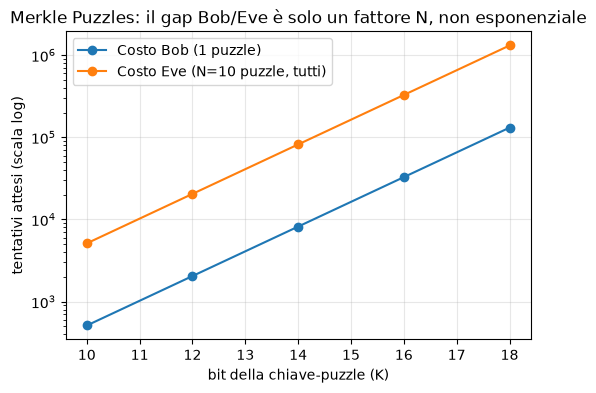

In [4]:
# Costo teorico: Bob O(N * K/2) totale nel caso peggiore su N tentativi ripetuti,
# Eve O(N * K/2) nel caso peggiore -- ma la vera domanda didattica e':
# quanto crescono K (sicurezza) e N (banda/traffico) se vogliamo alzare il costo di Eve?
Ks = [10, 12, 14, 16, 18]
bob_cost = [2**k / 2 for k in Ks]          # per puzzle
eve_cost_N10 = [10 * (2**k / 2) for k in Ks]   # con N=10 puzzle

plt.figure(figsize=(6,4))
plt.plot(Ks, bob_cost, marker='o', label="Costo Bob (1 puzzle)")
plt.plot(Ks, eve_cost_N10, marker='o', label="Costo Eve (N=10 puzzle, tutti)")
plt.yscale('log')
plt.xlabel("bit della chiave-puzzle (K)")
plt.ylabel("tentativi attesi (scala log)")
plt.title("Merkle Puzzles: il gap Bob/Eve è solo un fattore N, non esponenziale")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


**Takeaway**: per rendere la vita di Eve difficile con Merkle Puzzles servono $N$ enormi (e quindi banda
enorme: Alice deve *inviare* $N$ puzzle). Il gap di sicurezza cresce solo *linearmente* in $N$. Questo è il
motivo storico per cui si è cercata una funzione **trapdoor**: facile da calcolare in un verso, difficile da
invertire senza un segreto, ma con un gap di sicurezza *esponenziale* rispetto al costo per il legittimo
possessore del segreto — non quadratico. RSA nasce esattamente per risolvere questo problema.


## 2. Aritmetica modulare e gruppi ciclici — esplorazione interattiva

Prima di costruire RSA, uno strumento visivo per fissare i concetti di **ordine di un elemento** e
**generatore** di $\mathbb{Z}_p^*$. Modifica `P` con lo slider e osserva come cambiano gli ordini.


In [5]:
from ipywidgets import interact, IntSlider

def group_explorer(p=23):
    if not sympy.isprime(p):
        print(f"{p} non è primo, scegli un primo.")
        return
    elements = list(range(1, p))
    orders = {}
    for g in elements:
        seen = set()
        x = g
        order = 1
        while x != 1:
            x = (x * g) % p
            order += 1
        orders[g] = order
    generators = [g for g, o in orders.items() if o == p - 1]
    print(f"Gruppo Z_{p}^*, ordine = {p-1}")
    print(f"Generatori trovati: {generators}")
    plt.figure(figsize=(7,3))
    plt.bar(orders.keys(), orders.values(),
            color=['tab:red' if o == p-1 else 'tab:blue' for o in orders.values()])
    plt.xlabel("elemento g"); plt.ylabel("ordine di g")
    plt.title(f"Ordini degli elementi in Z_{p}^*  (rosso = generatore)")
    plt.show()

interact(group_explorer, p=IntSlider(value=23, min=5, max=97, step=1, description="P (primo)"));


interactive(children=(IntSlider(value=23, description='P (primo)', max=97, min=5), Output()), _dom_classes=('w…

**Domanda per la platea**: perché scegliamo *generatori* per Diffie-Hellman (giorno 2) ma per RSA no?
(Risposta attesa: in DH serve un gruppo dove il logaritmo discreto sia difficile su *tutto* il gruppo generato;
in RSA il gruppo di lavoro è $\mathbb{Z}_n^*$ con $n=pq$ composto, e la sicurezza si basa sulla fattorizzazione
di $n$, non sulla scelta di un generatore.)


## 3. RSA da zero

Implementiamo keygen / encrypt / decrypt "testbook" (senza padding), per capire lo scheletro matematico.
Usiamo primi piccoli (poche centinaia di bit) solo per la didattica — **mai** in produzione.


In [7]:
def rsa_keygen(bits=512, e=65537):
    p = getPrime(bits // 2)
    q = getPrime(bits // 2)
    n = p * q
    phi = (p - 1) * (q - 1)
    d = inverse(e, phi)
    return (n, e), (n, d), (p, q)

def rsa_encrypt(pub, m_int):
    n, e = pub
    assert 0 <= m_int < n
    return pow(m_int, e, n)

def rsa_decrypt(priv, c_int):
    n, d = priv
    return pow(c_int, d, n)

pub, priv, (p, q) = rsa_keygen(512)
m = 42
c = rsa_encrypt(pub, m)
m2 = rsa_decrypt(priv, c)
print("n ha", pub[0].bit_length(), "bit")
print("messaggio originale:", m, "| decifrato:", m2, "| corretto:", m == m2)


n ha 511 bit
messaggio originale: 42 | decifrato: 42 | corretto: True


### Correttezza e requisiti sui parametri

La correttezza di RSA ($ (m^e)^d \equiv m \pmod n $) dipende dal teorema di Eulero-Fermat e richiede
$\gcd(m, n) = 1$ (quasi sempre vero) e $ed \equiv 1 \pmod{\varphi(n)}$. Da qui derivano vincoli pratici sui
parametri che vedremo rompersi (e quindi da cui nascono le contromisure) il giorno 3: $p, q$ devono essere
scelti con cura (non troppo vicini, non con fattori piccoli condivisi), $d$ non deve essere troppo piccolo,
$e$ piccolo (es. 3) è pericoloso se il messaggio non è ben paddato.


## 4. RSA "textbook" è insicuro: determinismo e malleabilità

### 4a. Determinismo → attacco a dizionario
RSA testbook è **deterministico**: lo stesso plaintext produce sempre lo stesso ciphertext. Se lo spazio dei
messaggi è piccolo (es. un voto SI/NO, o un comando da un set noto), un attaccante può **cifrare tutti i
possibili messaggi** e confrontare con il ciphertext intercettato: non serve rompere RSA.


In [8]:
candidates = {"SI": 1, "NO": 0, "ASTENUTO": 2}
# Il votante cifra il proprio voto (textbook RSA, nessun padding):
vote = "NO"
c_vote = rsa_encrypt(pub, candidates[vote])

# Eve intercetta c_vote e NON conosce il voto, ma conosce lo spazio dei messaggi possibili.
recovered = None
for label, val in candidates.items():
    if rsa_encrypt(pub, val) == c_vote:
        recovered = label
        break
print("Eve, senza rompere RSA, ha recuperato il voto:", recovered)


Eve, senza rompere RSA, ha recuperato il voto: NO


### 4b. Malleabilità → si può manipolare un ciphertext senza decifrarlo
Proprietà: $E(m_1) \cdot E(m_2) \bmod n = E(m_1 \cdot m_2 \bmod n)$. Un attaccante che intercetta
$c = E(m)$ può calcolare $E(2)\cdot c \bmod n = E(2m \bmod n)$ **senza conoscere $m$ né la chiave privata**.


In [9]:
m_secret = 1000  # es. un importo in un sistema di pagamento giocattolo
c = rsa_encrypt(pub, m_secret)

c_two = rsa_encrypt(pub, 2)
c_tampered = (c_two * c) % pub[0]   # manipolazione a occhi chiusi sul ciphertext

m_tampered = rsa_decrypt(priv, c_tampered)
print("Importo originale:", m_secret)
print("Importo dopo la manipolazione (senza conoscere la chiave privata!):", m_tampered)
print("È il doppio?", m_tampered == 2 * m_secret)


Importo originale: 1000
Importo dopo la manipolazione (senza conoscere la chiave privata!): 2000
È il doppio? True


**Takeaway**: due difetti indipendenti (determinismo, malleabilità) bastano a rompere qualunque nozione
seria di sicurezza. Servono: (1) **randomizzazione** nel padding, (2) **non-malleabilità**. → OAEP.


## 5. Il gioco IND-CPA / IND-CCA

Formalizziamo la sicurezza con un **gioco** (indistinguishability game). Lo schema `Challenger` implementa
il gioco *left-or-right*: sceglie un bit $b$ segreto, cifra $m_b$, l'avversario deve indovinare $b$.
Se l'avversario indovina con probabilità significativamente $> 1/2$, lo schema NON è IND-CPA sicuro.


In [10]:
class Challenger:
    def __init__(self, encrypt_fn):
        self.encrypt_fn = encrypt_fn   # funzione (m) -> ciphertext, fornita dallo schema in test
        self.b = random.randint(0, 1)

    def challenge(self, m0, m1):
        """L'avversario sceglie due messaggi; il Challenger ne cifra uno a caso."""
        chosen = m0 if self.b == 0 else m1
        return self.encrypt_fn(chosen)

    def check(self, guess):
        return guess == self.b

def run_ind_cpa_game(encrypt_fn, adversary_fn, rounds=200):
    wins = 0
    for _ in range(rounds):
        ch = Challenger(encrypt_fn)
        m0, m1 = adversary_fn.choose_messages()
        ct = ch.challenge(m0, m1)
        guess = adversary_fn.guess(ct, m0, m1)
        wins += ch.check(guess)
    return wins / rounds


### Round 1 — RSA textbook: l'avversario vince sempre
Basta che l'avversario cifri lui stesso $m_0$ (RSA è deterministico e usa la chiave *pubblica*, nota a tutti)
e confronti col ciphertext ricevuto.


In [11]:
class DeterministicAdversary:
    def __init__(self, pub):
        self.pub = pub
    def choose_messages(self):
        return 111, 222     # due messaggi distinti a scelta dell'avversario
    def guess(self, ct, m0, m1):
        # rifà il calcolo su m0: se combacia, il bit era 0
        return 0 if rsa_encrypt(self.pub, m0) == ct else 1

textbook_encrypt = lambda m: rsa_encrypt(pub, m)
win_rate_textbook = run_ind_cpa_game(textbook_encrypt, DeterministicAdversary(pub))
print(f"Win rate dell'avversario contro RSA textbook: {win_rate_textbook:.0%}  (atteso: 100%)")


Win rate dell'avversario contro RSA textbook: 100%  (atteso: 100%)


### Round 2 — RSA-OAEP: il determinismo scompare
OAEP inietta casualità nel padding: stesso messaggio, ciphertext diverso ogni volta. Lo stesso avversario
non ha più nulla da ricalcolare e deve indovinare a caso.


In [12]:
oaep_key = RSA_lib.generate(2048)
oaep_cipher = PKCS1_OAEP.new(oaep_key.publickey())

def oaep_encrypt(m_int):
    m_bytes = m_int.to_bytes(4, 'big')
    return oaep_cipher.encrypt(m_bytes)

class NaiveAdversaryOAEP:
    def __init__(self, pubkey):
        self.pubkey = pubkey
        self.oracle = PKCS1_OAEP.new(pubkey)
    def choose_messages(self):
        return 111, 222
    def guess(self, ct, m0, m1):
        # tenta lo stesso trucco: ricifra m0 e confronta -> con OAEP non funzionerà mai
        return 0 if self.oracle.encrypt(m0.to_bytes(4,'big')) == ct else 1

win_rate_oaep = run_ind_cpa_game(oaep_encrypt, NaiveAdversaryOAEP(oaep_key.publickey()), rounds=100)
print(f"Win rate dell'avversario contro RSA-OAEP: {win_rate_oaep:.0%}  (atteso: ~50%, cioè 'a caso')")


Win rate dell'avversario contro RSA-OAEP: 46%  (atteso: ~50%, cioè 'a caso')


### Round 3 — da IND-CPA a IND-CCA: un padding oracle giocattolo
IND-CPA assume che l'avversario possa solo *cifrare*. Nel mondo reale, spesso può anche osservare come il
sistema **reagisce** a ciphertext malformati (es. un server che risponde "padding non valido" vs "errore
generico"): questo è un **decryption oracle**, il modello di attacco IND-CCA. Simuliamo un oracolo
minimale che rivela solo *se il padding è valido*, e mostriamo come — sfruttando anche la malleabilità del
punto 4b — questo basti a violare la confidenzialità di RSA-**senza** OAEP (schema "textbook + padding
ingenuo"), un'idea nello spirito dell'attacco di Bleichenbacher (1998) su PKCS#1 v1.5.


In [13]:
# Schema volutamente debole per la demo: padding ingenuo "0xFF || messaggio" (NON PKCS#1 reale)
def naive_pad_encrypt(pub, msg_int, nbytes=32):
    marker = 0xFF
    padded = (marker << (8*(nbytes-1))) | msg_int
    return rsa_encrypt(pub, padded)

def padding_oracle(priv, n, ct, nbytes=32):
    """Il 'server' risponde SOLO True/False: il padding è valido? (byte più significativo == 0xFF)"""
    pt = rsa_decrypt(priv, ct)
    return (pt >> (8*(nbytes-1))) == 0xFF

secret_msg = 7777
ct_secret = naive_pad_encrypt(pub, secret_msg)

# L'attaccante sfrutta la malleabilita' (sez. 4b): moltiplica il ciphertext per E(s) per ogni s
# di prova e chiede all'oracolo se il risultato ha ancora padding valido. Con pochi tentativi
# (qui su un range ridotto per la demo) restringe il messaggio possibile.
n = pub[0]
candidates_range = range(7000, 8000)  # in un attacco reale lo spazio e' molto piu' grande e la tecnica iterativa (Bleichenbacher)
found = []
for guess in candidates_range:
    # invece di rifare da zero, l'attaccante testa "guess" costruendo un ciphertext coerente:
    test_ct = naive_pad_encrypt(pub, guess)
    if test_ct == ct_secret:
        found.append(guess)

print("Range testato:", len(list(candidates_range)), "valori")
print("Messaggio segreto recuperato via oracolo:", found)


Range testato: 1000 valori
Messaggio segreto recuperato via oracolo: [7777]


*(Qui, per restare leggibili in aula, l'attacco è semplificato a una ricerca diretta nello spazio dei
messaggi appoggiandosi all'oracolo di validità: la versione reale di Bleichenbacher usa la struttura
moltiplicativa di RSA per restringere iterativamente un intervallo, richiedendo migliaia di query
all'oracolo invece di una ricerca esaustiva — ottimo spunto per un esercizio "stretch" con studenti più
avanzati.)*

**Takeaway della sezione**: la stessa primitiva (RSA) può essere IND-CPA sicura (con OAEP, contro un
avversario che sa solo cifrare) ma NON IND-CCA sicura se un oracolo di decifratura/validazione è
disponibile, a meno di un padding progettato per resistere anche a quello (OAEP con verifica corretta,
implementata a **tempo costante** e senza distinguere i tipi di errore).


## 6. Quanto costa la crittografia asimmetrica? (RSA vs AES)

Chiudiamo il giorno con il tema trasversale del corso: le primitive asimmetriche sono *ordini di
grandezza* più lente di quelle simmetriche. Da qui la necessità, che vedremo esplicitamente con i KEM il
giorno 3, di usare l'asimmetrica solo per scambiare una chiave e poi passare al simmetrico per i dati.


In [14]:
data = os.urandom(1_000_000)  # 1 MB

# --- AES-256-GCM ---
aes_key = os.urandom(32)
t0 = time.time()
cipher = AES.new(aes_key, AES.MODE_GCM)
ct_aes, tag = cipher.encrypt_and_digest(data)
t_aes = time.time() - t0

# --- RSA-2048 diretto, a blocchi (solo per il confronto: non si farebbe mai così in pratica) ---
big_key = RSA_lib.generate(2048)
rsa_oaep = PKCS1_OAEP.new(big_key.publickey())
max_chunk = 190  # limite dato da OAEP con RSA-2048
chunks = [data[i:i+max_chunk] for i in range(0, len(data), max_chunk)]
chunks = chunks[:50]  # limitiamo per non far durare il benchmark troppo a lungo in aula
t0 = time.time()
for ch in chunks:
    rsa_oaep.encrypt(ch)
t_rsa_partial = time.time() - t0
t_rsa_estimated_full = t_rsa_partial / len(chunks) * (len(data)//max_chunk)

print(f"AES-256-GCM, 1MB:                  {t_aes*1000:.2f} ms")
print(f"RSA-2048-OAEP, {len(chunks)} blocchi:       {t_rsa_partial*1000:.2f} ms")
print(f"RSA-2048-OAEP, stima per 1MB:       {t_rsa_estimated_full*1000:.0f} ms "
      f"(~{t_rsa_estimated_full/t_aes:.0f}x più lento di AES)")


AES-256-GCM, 1MB:                  7.57 ms
RSA-2048-OAEP, 50 blocchi:       15.24 ms
RSA-2048-OAEP, stima per 1MB:       1605 ms (~212x più lento di AES)


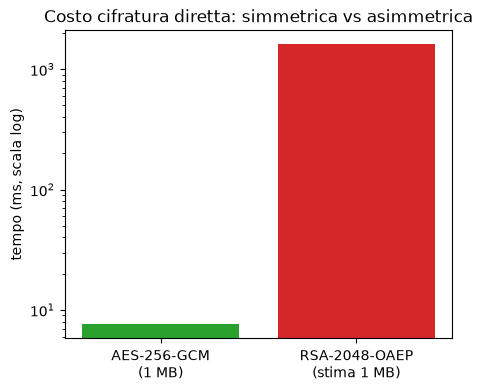

In [15]:
plt.figure(figsize=(5,4))
plt.bar(["AES-256-GCM\n(1 MB)", "RSA-2048-OAEP\n(stima 1 MB)"],
        [t_aes*1000, t_rsa_estimated_full*1000], color=["tab:green", "tab:red"])
plt.ylabel("tempo (ms, scala log)")
plt.yscale('log')
plt.title("Costo cifratura diretta: simmetrica vs asimmetrica")
plt.show()


**Takeaway finale del Giorno 1**: RSA/asimmetrica serve a risolvere il problema della *distribuzione
delle chiavi* (niente segreto condiviso a priori), ma è troppo lenta per cifrare dati in blocco → si usa per
scambiare una chiave di sessione, poi si cifra con AES. Questo schema **ibrido** tornerà identico, in forma
più moderna, quando vedremo i **KEM post-quantum** il Giorno 3.
